## 1. Imports & Configuration

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

BLEU   = "#2E86AB"   # Classe 0 - pas de risque
ROUGE  = "#D62828"   # Classe 1 - risque
VERT   = "#2DC653"
GRIS   = "#6C757D"
PALETTE = [BLEU, ROUGE]

PLOTS_DIR = "/Users/madeleine/Desktop/ml-poc-project/plots"
import os; os.makedirs(PLOTS_DIR, exist_ok=True)

## 2. Chargement & Selection des Variables

On charge uniquement 100 000 lignes et les colonnes "utiles" depuis le dataset brut (200+ colonnes).

In [ ]:
COLONNES = {
    'mager'   : 'Age_Mere',
    'bmi'     : 'IMC_Mere',
    'cig_0'   : 'Tabac_Avant_Grossesse',
    'cig_1'   : 'Tabac_Trim1',
    'cig_3'   : 'Tabac_Trim3',
    'precare' : 'Mois_Debut_Suivi',
    'previs'  : 'Nb_Visites_Prenatales',
    'wic'     : 'Aide_Sociale_WIC',
    'rf_phype': 'Hypertension_Chronique',
    'rf_pdiab': 'Diabete_Chronique',
    'pay'     : 'Type_Assurance',
    'wtgain'  : 'Prise_Poids_Lbs',
    # Nouvelles features — fort signal médical
    'dplural'  : 'Pluralite',
    'rf_ppterm': 'ATCD_Premature',
    'rf_artec' : 'PMA',
    'rf_inftr' : 'Traitement_Infertilite',
    'priordead': 'ATCD_Mort_Foetale',
    'rf_ehype' : 'Eclampsie',
    'rf_ghype' : 'HTA_Gestationnelle',
    'rf_gdiab' : 'Diabete_Gestationnel',
    'ab_nicu'  : 'Target_Risk'
}

df = pd.read_csv(RAW_PATH, usecols=list(COLONNES.keys()), nrows=100_000)
df = df.rename(columns=COLONNES)
df = df[df['Target_Risk'].isin(['Y', 'N'])].copy()
df['Target_Risk'] = df['Target_Risk'].map({'Y': 1, 'N': 0})

print(f"✅ Chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Classe 0 : {(df.Target_Risk==0).sum():,}  |  Classe 1 : {(df.Target_Risk==1).sum():,}")


## 3. Valeurs Manquantes & Valeurs Speciales CDC

### Pourquoi c'est critique ?
Le CDC encode les non-reponses avec des **valeurs sentinelles numeriques** plutot que de laisser des cases vides/NaN

| Variable | Valeur sentinelle | Signification |
|---|---|---|
| `IMC_Mere` | 99.9 | Inconnu |
| `Prise_Poids_Lbs` | 99 | Inconnu |
| `Tabac_Avant_Grossesse` | 99 | Inconnu |
| `Tabac_Trim1` | 99 | Inconnu |
| `Mois_Debut_Suivi` | 99 | Inconnu |
| `Nb_Visites_Prenatales` | 99 | Inconnu |
| `Type_Assurance` | 9 | Inconnu |

In [60]:
from skrub import TableReport

TableReport(df)

Processing column  12 / 12


,,,,,,,,,,,,


Aucun NaN -> confirme que les manquants sont masques en sentinelles CDC

In [ ]:
SENTINELLES = {
    'IMC_Mere'              : [99.9],
    'Prise_Poids_Lbs'       : [99],
    'Tabac_Avant_Grossesse' : [99],
    'Tabac_Trim1'           : [99],
    'Tabac_Trim3'           : [99],
    'Mois_Debut_Suivi'      : [99],
    'Nb_Visites_Prenatales' : [99],
    'Type_Assurance'        : [9],
    'ATCD_Mort_Foetale'     : [99],
}

print("Valeurs sentinelles detectees :")
print("-" * 52)
for col, vals in SENTINELLES.items():
    if col in df.columns:
        n = df[col].isin(vals).sum()
        pct = n / len(df) * 100
        df[col] = df[col].replace(vals, np.nan)
        print(f"  {col:<30} {n:>6,}  ({pct:.1f}%)")


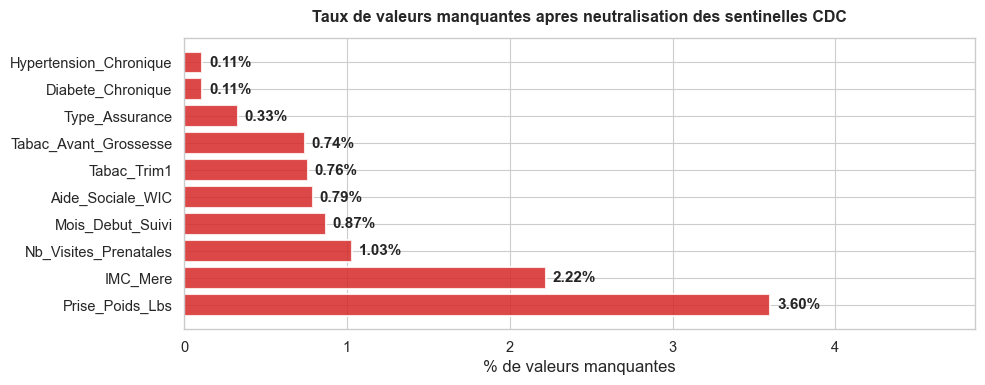

In [62]:
# Visualisation des NaN apres nettoyage
nan_df = df.isnull().sum().reset_index()
nan_df.columns = ['Variable', 'NaN']
nan_df['NaN_%'] = (nan_df['NaN'] / len(df) * 100).round(2)
nan_df = nan_df.sort_values('NaN_%', ascending=False)
cols_avec_nan = nan_df[nan_df['NaN'] > 0]

fig, ax = plt.subplots(figsize=(10, 4))
if not cols_avec_nan.empty:
    bars = ax.barh(cols_avec_nan['Variable'], cols_avec_nan['NaN_%'],
                   color=ROUGE, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.bar_label(bars, fmt='%.2f%%', padding=5, fontsize=11, fontweight='bold')
    ax.set_xlabel("% de valeurs manquantes", fontsize=12)
    ax.set_xlim(0, cols_avec_nan['NaN_%'].max() * 1.35)
else:
    ax.text(0.5, 0.5, "Aucune valeur manquante", ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color=VERT)

ax.set_title("Taux de valeurs manquantes apres neutralisation des sentinelles CDC",
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/0_missing_values.png', dpi=300)
plt.show(); plt.close()

## 4. Distribution de la Target - Desequilibre des Classes

Notre metrique prioritaire sera le **Recall** (ne pas rater les vrais cas a risque)

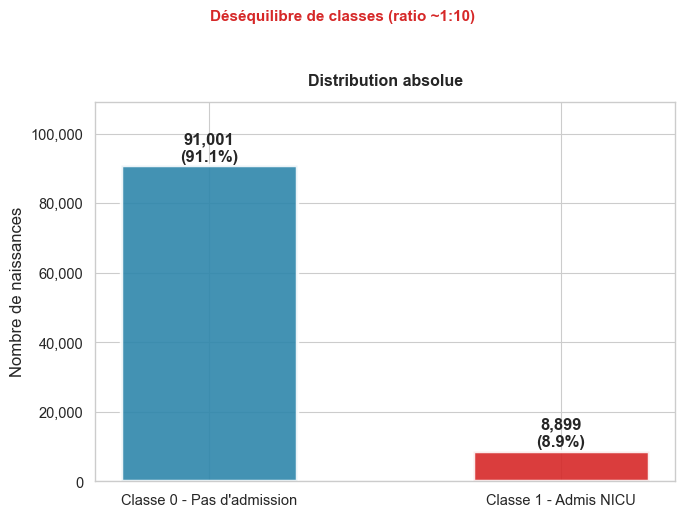

Classe 0 : 91,001  (91.1%)
Classe 1 : 8,899  (8.9%)
Ratio : 1 positif pour 10 negatifs = déséquilibre significatif
-> SMOTE + class_weight='balanced' requis


In [63]:
counts = df['Target_Risk'].value_counts().sort_index()
total = len(df)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(["Classe 0 - Pas d'admission", "Classe 1 - Admis NICU"],
              counts.values, color=PALETTE, edgecolor='white', linewidth=2.5,
              alpha=0.9, width=0.5)
for bar, (k, v) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{v:,}\n({v/total*100:.1f}%)", ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_ylabel("Nombre de naissances", fontsize=12)
ax.set_title("Distribution absolue", fontweight='bold', pad=12)
ax.set_ylim(0, counts.max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle("Déséquilibre de classes (ratio ~1:10)",
             fontsize=11, color=ROUGE, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/1_distribution_target.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

print(f"Classe 0 : {counts[0]:,}  ({counts[0]/total*100:.1f}%)")
print(f"Classe 1 : {counts[1]:,}  ({counts[1]/total*100:.1f}%)")
print(f"Ratio : 1 positif pour {counts[0]/counts[1]:.0f} negatifs = déséquilibre significatif")
print("-> SMOTE + class_weight='balanced' requis")

## 5. Statistiques Descriptives

In [ ]:
print("=" * 70)
print("VARIABLES NUMÉRIQUES")
print("=" * 70)
cols_num = ['Age_Mere', 'IMC_Mere', 'Tabac_Avant_Grossesse', 'Tabac_Trim1', 'Tabac_Trim3',
            'Mois_Debut_Suivi', 'Prise_Poids_Lbs', 'ATCD_Mort_Foetale']
display(df[cols_num].describe().T.round(2))

print("\n" + "=" * 70)
print("VARIABLES CATÉGORIELLES")
print("=" * 70)
cat_cols = ['Aide_Sociale_WIC', 'Hypertension_Chronique', 'Diabete_Chronique',
            'Type_Assurance', 'ATCD_Premature', 'PMA', 'Traitement_Infertilite',
            'Eclampsie', 'HTA_Gestationnelle', 'Diabete_Gestationnel']
for col in cat_cols:
    if col in df.columns:
        print(f"\n> {col}")
        vc = df[col].value_counts(dropna=False)
        for k, v in vc.items():
            rate = df[df[col]==k]['Target_Risk'].mean() if k is not np.nan else np.nan
            print(f"   {str(k):<10} {v:>7,}  ({v/len(df)*100:.1f}%)  → NICU: {rate:.1%}" if not (isinstance(rate,float) and np.isnan(rate)) else f"   {str(k):<10} {v:>7,}  ({v/len(df)*100:.1f}%)")


## 6. Distributions des Variables Continues

Si les distributions sont differentes entre classe 0 et classe 1 -> la variable est potentiellement informative.

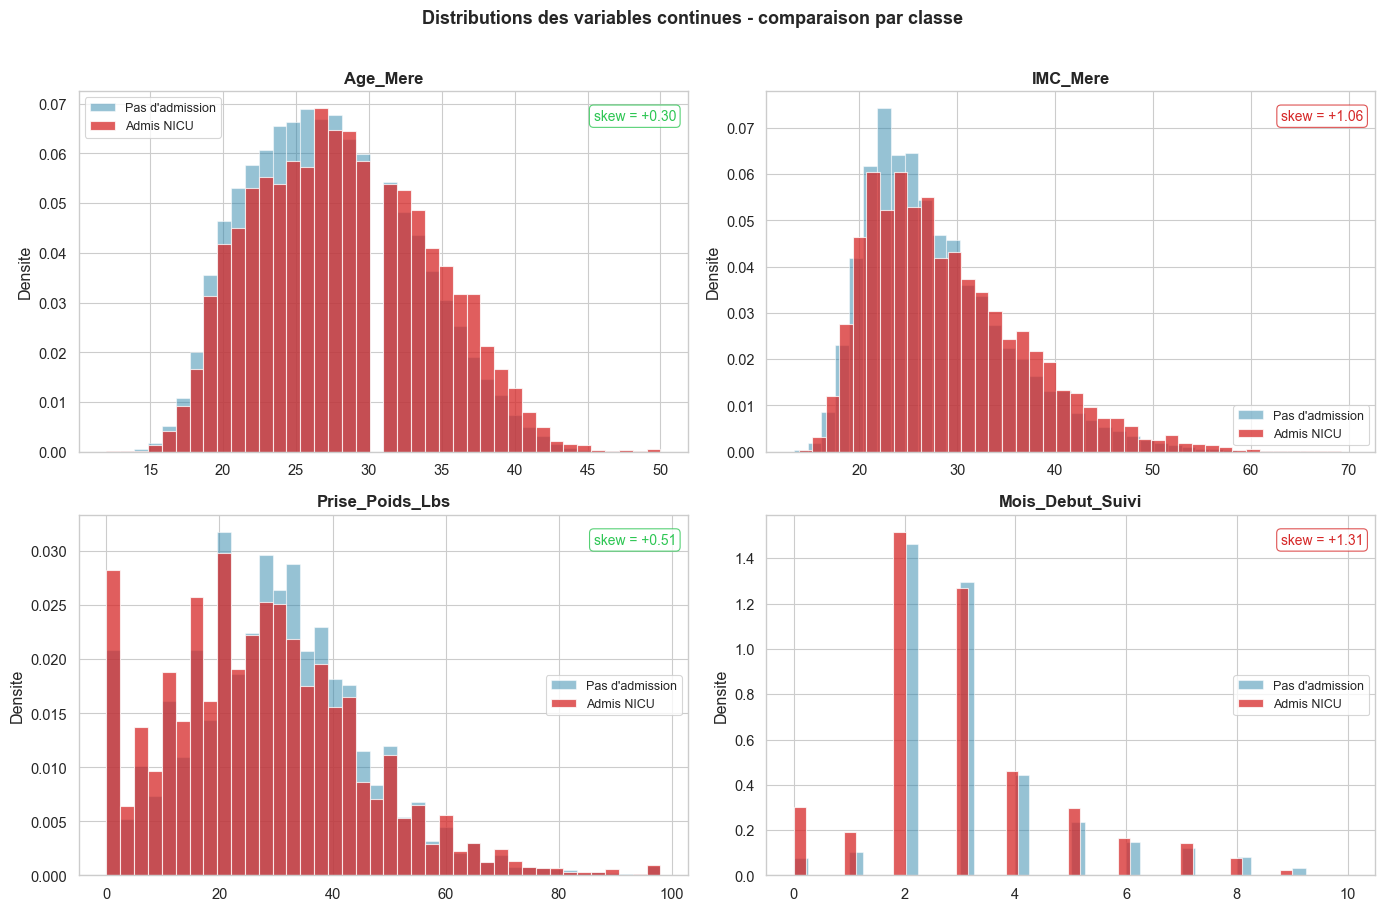

Interpretation de la skewness :
  |skew| < 0.5  -> quasi-symetrique        -> StandardScaler ok
  |skew| < 1.0  -> legerement asymetrique   -> StandardScaler acceptable
  |skew| >= 1.0 -> fortement asymetrique    -> RobustScaler ou log-transform

  Age_Mere                      skew = +0.30  -> StandardScaler ok
  IMC_Mere                      skew = +1.06  -> RobustScaler recommande
  Prise_Poids_Lbs               skew = +0.51  -> StandardScaler ok
  Mois_Debut_Suivi              skew = +1.31  -> RobustScaler recommande


In [65]:
cols_hist = ['Age_Mere', 'IMC_Mere', 'Prise_Poids_Lbs', 'Mois_Debut_Suivi']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flatten(), cols_hist):
    for val, color, label, alpha in [
        (0, BLEU,  "Pas d'admission", 0.5),
        (1, ROUGE, "Admis NICU",      0.75)
    ]:
        subset = df[df['Target_Risk'] == val][col].dropna()
        ax.hist(subset, bins=40, alpha=alpha, color=color, label=label, density=True)
    
    skew_val = df[col].dropna().skew()
    couleur_skew = ROUGE if abs(skew_val) > 1 else VERT
    ax.set_title(f"{col}", fontweight='bold', fontsize=12)
    ax.set_ylabel("Densite")
    ax.legend(fontsize=9)
    ax.text(0.98, 0.95, f"skew = {skew_val:+.2f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color=couleur_skew,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=couleur_skew, alpha=0.8))

plt.suptitle("Distributions des variables continues - comparaison par classe",
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/2_distributions_continues.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

print("Interpretation de la skewness :")
print("  |skew| < 0.5  -> quasi-symetrique        -> StandardScaler ok")
print("  |skew| < 1.0  -> legerement asymetrique   -> StandardScaler acceptable")
print("  |skew| >= 1.0 -> fortement asymetrique    -> RobustScaler ou log-transform")
print()
for col in cols_hist:
    s = df[col].dropna().skew()
    flag = "-> RobustScaler recommande" if abs(s) > 1 else "-> StandardScaler ok"
    print(f"  {col:<28}  skew = {s:+.2f}  {flag}")

## 7. Analyse Comportementale - Impact du Tabac

Le tabac est notre **variable comportementale principale**.  
On decoupe en tranches (bins) pour visualiser si le taux de risque augmente avec l'intensite du tabagisme.

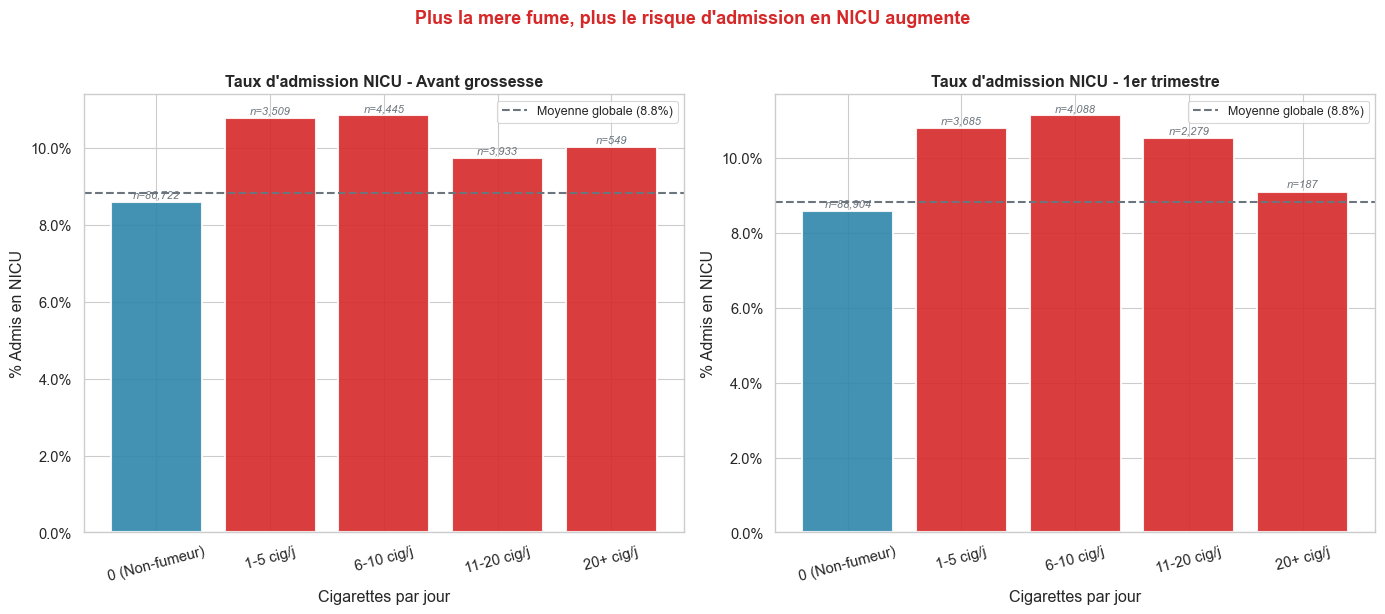

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, titre in [
    (axes[0], 'Tabac_Avant_Grossesse', 'Avant grossesse'),
    (axes[1], 'Tabac_Trim1',           '1er trimestre')
]:
    df_t = df[[col, 'Target_Risk']].dropna().copy()
    bins   = [-1, 0, 5, 10, 20, 9999]
    labels = ['0 (Non-fumeur)', '1-5 cig/j', '6-10 cig/j', '11-20 cig/j', '20+ cig/j']
    df_t['Tranche'] = pd.cut(df_t[col], bins=bins, labels=labels)
    
    stats_tab = df_t.groupby('Tranche', observed=True)['Target_Risk'].agg(
        Taux_Risque='mean', Effectif='count').reset_index()
    stats_tab['Taux_Pct'] = stats_tab['Taux_Risque'] * 100
    moy_glob = df_t['Target_Risk'].mean() * 100
    
    colors = [ROUGE if t >= moy_glob else BLEU for t in stats_tab['Taux_Pct']]
    bars = ax.bar(stats_tab['Tranche'], stats_tab['Taux_Pct'],
                  color=colors, alpha=0.9, edgecolor='white', linewidth=1.5)
    
    for bar, row in zip(bars, stats_tab.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"n={row.Effectif:,}", ha='center', va='bottom',
                fontsize=8, color=GRIS, fontstyle='italic')
    
    ax.axhline(moy_glob, color=GRIS, linestyle='--', linewidth=1.5,
               label=f'Moyenne globale ({moy_glob:.1f}%)')
    ax.set_title(f"Taux d'admission NICU - {titre}", fontweight='bold')
    ax.set_xlabel("Cigarettes par jour")
    ax.set_ylabel("% Admis en NICU")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=9)

plt.suptitle("Plus la mere fume, plus le risque d'admission en NICU augmente",
             fontweight='bold', color=ROUGE, fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/3_tabac_vs_risque.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

## 8. Variables Categorielles vs Target

On visualise le taux d'admission pour chaque modalite.  
Si le taux varie significativement -> la variable est informative pour le modele.

In [ ]:
LABELS_ASSURANCE = {
    1: 'Medicaid', 2: 'Privee', 3: 'CHIP',
    4: 'Self-pay', 5: 'Autre', 6: 'Inconnu', 8: 'Non indiquee'
}
df['Type_Assurance_Label'] = df['Type_Assurance'].map(LABELS_ASSURANCE).fillna('Inconnu')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# WIC
ax = axes[0]
wic = df.groupby('Aide_Sociale_WIC')['Target_Risk'].agg(['mean','count']).reset_index()
wic['Taux'] = wic['mean'] * 100
colors_wic = [BLEU if w == 'N' else ROUGE for w in wic['Aide_Sociale_WIC']]
bars = ax.bar(wic['Aide_Sociale_WIC'], wic['Taux'],
              color=colors_wic, edgecolor='white', linewidth=2, alpha=0.9, width=0.4)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontweight='bold', fontsize=11)
ax.set_title("Aide Sociale WIC -> Risque NICU", fontweight='bold')
ax.set_xlabel("Beneficiaire WIC (N=Non, Y=Oui)")
ax.set_ylabel("% Admis en NICU")
ax.set_ylim(0, wic['Taux'].max() * 1.3)

# Type Assurance
ax = axes[1]
assur = df.groupby('Type_Assurance_Label')['Target_Risk'].mean().reset_index()
assur['Taux'] = assur['Target_Risk'] * 100
assur = assur.sort_values('Taux', ascending=True)
moy_a = assur['Taux'].mean()
colors_a = [ROUGE if t > moy_a else BLEU for t in assur['Taux']]
hb = ax.barh(assur['Type_Assurance_Label'], assur['Taux'],
             color=colors_a, alpha=0.9, edgecolor='white')
ax.bar_label(hb, fmt='%.1f%%', padding=3, fontsize=10)
ax.axvline(moy_a, color=GRIS, linestyle='--', linewidth=1.5,
           label=f'Moyenne {moy_a:.1f}%')
ax.set_title("Type d'Assurance -> Risque NICU", fontweight='bold')
ax.set_xlabel("% Admis en NICU")
ax.legend(fontsize=9)

# Pathologies
ax = axes[2]
pathos = {'Hypertension': 'Hypertension_Chronique', 'Diabete': 'Diabete_Chronique'}
x = np.arange(len(pathos))
w = 0.35
for j, (label, col) in enumerate(pathos.items()):
    for i, (cat, color) in enumerate([('N', BLEU), ('Y', ROUGE)]):
        subset = df[df[col] == cat]['Target_Risk']
        val = subset.mean() * 100 if len(subset) > 0 else 0
        ax.bar(x[j] + (i - 0.5) * w, val, w,
               color=color, alpha=0.9, edgecolor='white',
               label=('Sans' if color == BLEU else 'Avec') if j == 0 else "")
        ax.text(x[j] + (i - 0.5) * w, val + 0.1, f'{val:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(pathos.keys(), fontsize=11)
ax.set_ylabel("% Admis en NICU")
ax.set_title("Pathologies chroniques -> Risque", fontweight='bold')
handles = [plt.Rectangle((0,0),1,1,color=BLEU), plt.Rectangle((0,0),1,1,color=ROUGE)]
ax.legend(handles, ['Sans pathologie', 'Avec pathologie'], fontsize=9)

plt.suptitle("Impact des variables categorielles sur le risque NICU",
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/4_categoriques_vs_risque.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()


# Taux NICU par nouvelle variable catégorielle à fort signal
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
new_cat_vars = [
    ('ATCD_Premature',        'Antécédent prématurité'),
    ('PMA',                   'Procréation médicale assistée'),
    ('Traitement_Infertilite','Traitement infertilité'),
    ('Eclampsie',             'Éclampsie'),
    ('HTA_Gestationnelle',    'HTA Gestationnelle'),
    ('Diabete_Gestationnel',  'Diabète Gestationnel'),
]
for ax, (col, titre) in zip(axes.flatten(), new_cat_vars):
    if col in df.columns:
        grp = df.groupby(col)['Target_Risk'].agg(['mean','count']).reset_index()
        grp['Taux'] = grp['mean'] * 100
        colors = [ROUGE if t > df['Target_Risk'].mean()*100 else BLEU for t in grp['Taux']]
        bars = ax.bar(grp[col].astype(str), grp['Taux'], color=colors, alpha=0.85, edgecolor='white')
        ax.axhline(df['Target_Risk'].mean()*100, color=GRIS, linestyle='--', linewidth=1.5, label=f'Base: {df["Target_Risk"].mean()*100:.1f}%')
        ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=9)
        ax.set_title(titre, fontweight='bold')
        ax.set_ylabel('Taux NICU (%)')
        ax.legend(fontsize=8)
plt.suptitle("Nouvelles variables médicales vs Taux NICU", fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/4b_nouvelles_vars_medicales.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()
print("✅ Graphique nouvelles variables médicales sauvegardé")


## 9. Matrice de Correlation

Deux choses a reperer :
1. **Correlation avec `Target_Risk`** : signal direct pour le modele. Une correlation faible (|r| < 0.05) est un premier signal d'alerte.
2. **Correlation entre features** : si deux variables sont tres correlees entre elles (> 0.8), l'une est potentiellement redondante.

In [ ]:
cols_corr = ['Age_Mere', 'IMC_Mere', 'Tabac_Avant_Grossesse', 'Tabac_Trim1', 'Tabac_Trim3',
             'Mois_Debut_Suivi', 'Prise_Poids_Lbs', 'ATCD_Mort_Foetale', 'Target_Risk']

corr = df[cols_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.8, vmin=-0.4, vmax=0.4, ax=axes[0], annot_kws={'size': 9})
axes[0].set_title("Matrice de Corrélation", fontweight='bold')

corr_target = df[cols_corr].corrwith(df['Target_Risk']).drop('Target_Risk').sort_values(key=abs, ascending=False)
colors_bar = [ROUGE if v > 0 else BLEU for v in corr_target.values]
axes[1].barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_bar[::-1], alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Corrélations avec Target_Risk", fontweight='bold')
axes[1].set_xlabel("Coefficient de Pearson")
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/5_correlations.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

print("Correlations avec Target_Risk (triees par valeur absolue decroissante) :")
print("-" * 65)
for col, val in corr_target.items():
    bar = '|' * int(abs(val) * 100)
    print(f"  {col:<35} {val:+.4f}  {bar}")


## 10. Analyse Multivariee

On cherche des **interactions** entre variables qui pourraient mieux separer les deux classes.

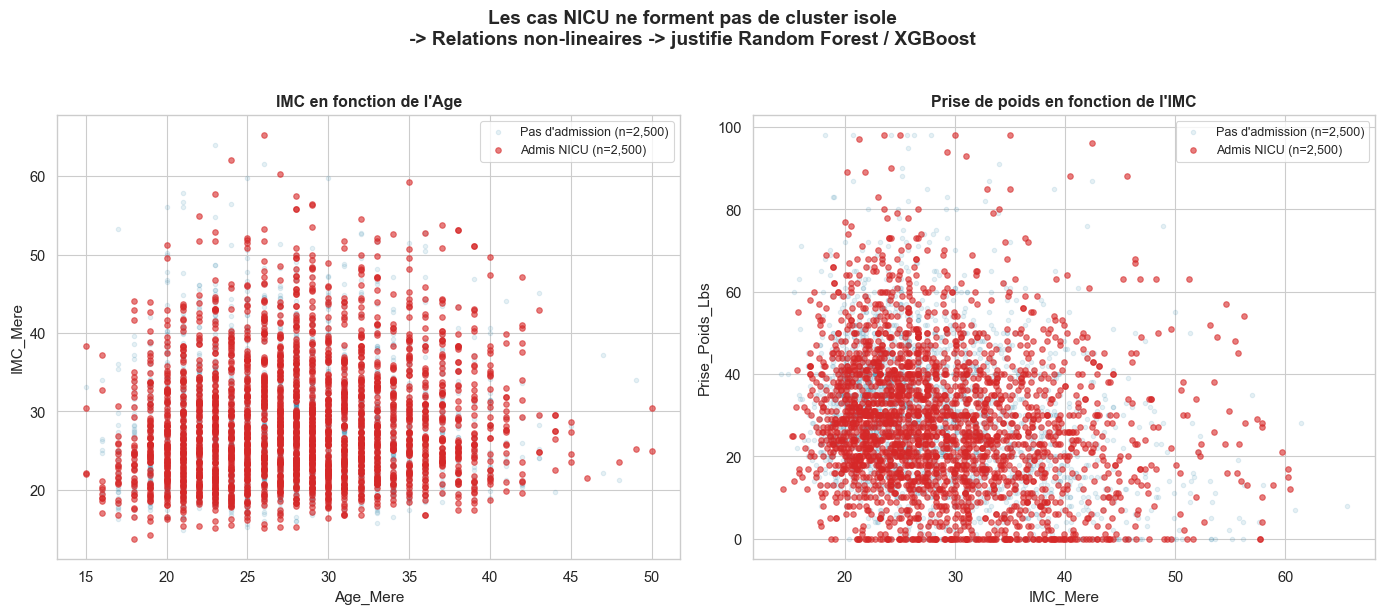

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (xcol, ycol, title) in zip(axes, [
    ('Age_Mere', 'IMC_Mere', "IMC en fonction de l'Age"),
    ('IMC_Mere', 'Prise_Poids_Lbs', "Prise de poids en fonction de l'IMC")
]):
    for val, color, label, alpha, size in [
        (0, BLEU,  "Pas d'admission", 0.12, 10),
        (1, ROUGE, "Admis NICU",      0.60, 16)
    ]:
        subset = df[df['Target_Risk'] == val].dropna(subset=[xcol, ycol])
        n = min(2500, len(subset))
        subset = subset.sample(n, random_state=42)
        ax.scatter(subset[xcol], subset[ycol], c=color,
                   label=f"{label} (n={n:,})", alpha=alpha, s=size)
    ax.set_xlabel(xcol, fontsize=11)
    ax.set_ylabel(ycol, fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle("Les cas NICU ne forment pas de cluster isole\n"
             "-> Relations non-lineaires -> justifie Random Forest / XGBoost",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/6_multivariate.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

On peut observer des valeurs abérrantes pour la prise de poids. 

## Focus prise de poids

In [72]:
# Valeurs médicalement impossibles → NaN
# Seuil IOM : 0-80 lbs couvre 99%+ des grossesses normales
df['Prise_Poids_Lbs'] = df['Prise_Poids_Lbs'].where(
    df['Prise_Poids_Lbs'].between(0, 80),
    other=np.nan
)

# Vérification rapide
print(f"Valeurs hors [0-80] lbs remplacées par NaN")
print(f"NaN Prise_Poids_Lbs : {df['Prise_Poids_Lbs'].isnull().sum():,}")
print(f"Min : {df['Prise_Poids_Lbs'].min():.1f}  |  Max : {df['Prise_Poids_Lbs'].max():.1f}")

Valeurs hors [0-80] lbs remplacées par NaN
NaN Prise_Poids_Lbs : 4,166
Min : 0.0  |  Max : 80.0


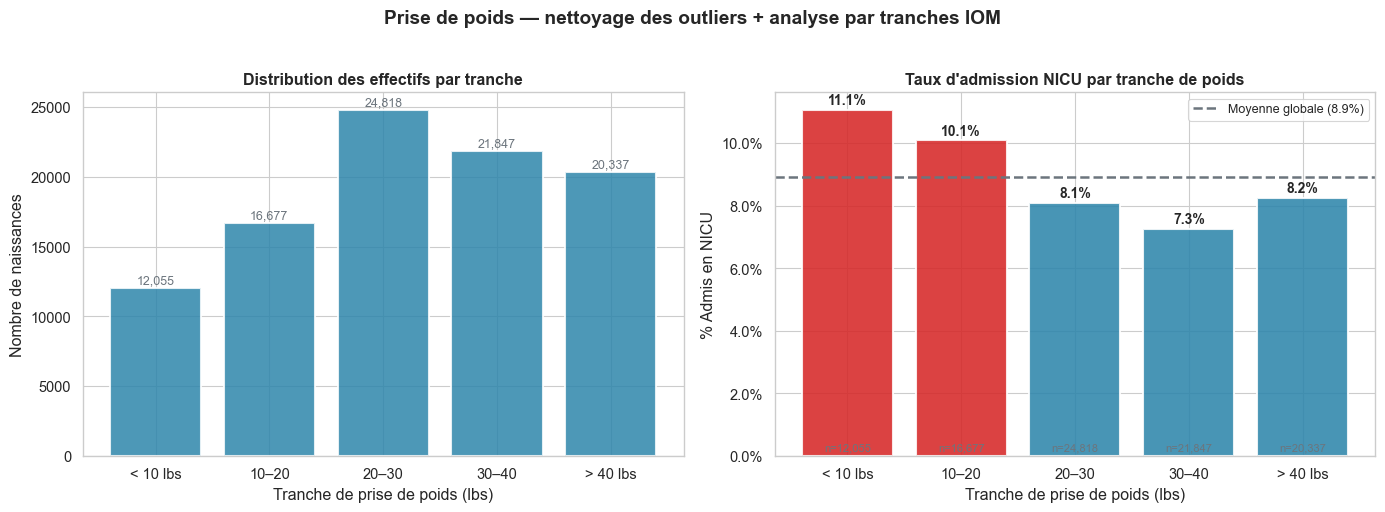

In [75]:
# Bins basés sur les recommandations IOM (Institute of Medicine)
# selon le niveau d'IMC de départ — médicalement cohérents
bins   = [-1, 10, 20, 30, 40, 80]
labels = ['< 10 lbs', '10–20', '20–30', '30–40', '> 40 lbs']

df['Poids_Bins'] = pd.cut(
    df['Prise_Poids_Lbs'],
    bins=bins,
    labels=labels
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique A : Distribution des effectifs par bin ────────────────
ax = axes[0]
counts_bins = df['Poids_Bins'].value_counts(sort=False)
ax.bar(counts_bins.index, counts_bins.values,
       color=BLEU, alpha=0.85, edgecolor='white', linewidth=1.5)
for i, (label, cnt) in enumerate(counts_bins.items()):
    ax.text(i, cnt + 100, f"{cnt:,}",
            ha='center', va='bottom', fontsize=9, color=GRIS)
ax.set_title("Distribution des effectifs par tranche", fontweight='bold')
ax.set_xlabel("Tranche de prise de poids (lbs)")
ax.set_ylabel("Nombre de naissances")

# ── Graphique B : Taux de risque NICU par bin ───────────────────────
ax2 = axes[1]
stats_bins = (df.groupby('Poids_Bins', observed=True)['Target_Risk']
                .agg(['mean', 'count'])
                .reset_index())
stats_bins.columns = ['Tranche', 'Taux', 'N']
stats_bins['Taux_Pct'] = stats_bins['Taux'] * 100

moy_g = df['Target_Risk'].mean() * 100
colors_bins = [ROUGE if t >= moy_g else BLEU for t in stats_bins['Taux_Pct']]

bars = ax2.bar(stats_bins['Tranche'], stats_bins['Taux_Pct'],
               color=colors_bins, alpha=0.88,
               edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, stats_bins.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f"{row['Taux_Pct']:.1f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2, 0.1,
             f"n={row['N']:,}",
             ha='center', va='bottom', fontsize=8, color=GRIS)

ax2.axhline(moy_g, color=GRIS, linestyle='--', linewidth=1.8,
            label=f'Moyenne globale ({moy_g:.1f}%)')
ax2.set_title("Taux d'admission NICU par tranche de poids", fontweight='bold')
ax2.set_xlabel("Tranche de prise de poids (lbs)")
ax2.set_ylabel("% Admis en NICU")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.legend(fontsize=9)

plt.suptitle("Prise de poids — nettoyage des outliers + analyse par tranches IOM",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/poids_bins.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

df = df.drop(columns=['Poids_Bins'])  # Les bins sont pour l'EDA seulement

## 11. Bilan EDA & Recommandations Preprocessing

In [ ]:
bilan = (
    "\n" +
    "+------------------------------------------------------------------------+\n" +
    "|               BILAN EDA - DECISIONS DE PREPROCESSING                   |\n" +
    "+------------------------------------------------------------------------+\n" +
    "|                                                                        |\n" +
    "|  1. DESEQUILIBRE (~9% positifs)                                        |\n" +
    "|     -> SMOTE sur le train set uniquement (jamais sur le test)          |\n" +
    "|     -> class_weight=\'balanced\' sur tous les modeles                   |\n" +
    "|     -> Metrique prioritaire : Recall + F-beta(2) (pas Accuracy)        |\n" +
    "|                                                                        |\n" +
    "|  2. VALEURS MANQUANTES                                                 |\n" +
    "|     -> Sentinelles CDC neutralisees (99 / 99.9 / 9 -> NaN)            |\n" +
    "|     -> Imputation mediane  pour les continues (robuste aux outliers)   |\n" +
    "|     -> Imputation mode     pour les categorielles                      |\n" +
    "|                                                                        |\n" +
    "|  3. OUTLIERS Prise_Poids : cap [0-80 lbs] selon recommandations IOM   |\n" +
    "|                                                                        |\n" +
    "|  4. ASYMETRIE (Tabac, Prise de poids) -> RobustScaler                 |\n" +
    "|                                                                        |\n" +
    "|  5. ENCODAGE                                                           |\n" +
    "|     -> Type_Assurance, vars Y/N/U : OHE (nominales, pas d\'ordre)      |\n" +
    "|     -> drop=\'first\' pour eviter la multicolinearite                   |\n" +
    "|                                                                        |\n" +
    "|  6. VARIABLES SUPPRIMEES                                               |\n" +
    "|     -> Nb_Visites_Prenatales : data leakage temporel                   |\n" +
    "|                                                                        |\n" +
    "|  7. NOUVELLES FEATURES AJOUTEES (signal fort)                         |\n" +
    "|     -> Grossesse_Multiple  (jumeaux 37%, triplets 87% NICU)           |\n" +
    "|     -> ATCD_Premature      (19.2% vs 8.5% base)                       |\n" +
    "|     -> Eclampsie           (27.1% vs 8.9% base) — plus fort signal    |\n" +
    "|     -> HTA_Gestationnelle  (16.8% vs 8.9% base)                       |\n" +
    "|     -> Diabete_Gestationnel(12.3% vs 8.9% base)                       |\n" +
    "|     -> PMA / Trt_Infertilite (21-24% vs 8.9% base)                   |\n" +
    "|     -> ATCD_Mort_Foetale   (jusqu\'a 16% vs 8.9% base)                |\n" +
    "|     -> Tabac_Trim3         (corr +0.142, signal > T1)                 |\n" +
    "|     -> Evol_Tabac, Suivi_T1 (feature engineering)                     |\n" +
    "|                                                                        |\n" +
    "|  8. VALIDATION                                                         |\n" +
    "|     -> StratifiedKFold k=5 (preserve le ratio 9/91%)                  |\n" +
    "|     -> SMOTE dans pipeline CV (evite data leakage dans Optuna)        |\n" +
    "+------------------------------------------------------------------------+\n"
)
print(bilan)
print(f"Dataset final : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"NaN restants  : {df.isnull().sum().sum():,}")
print(f"\nDistribution finale de la target :")
print(f"  Classe 0 (Pas d\'admission) : {(df.Target_Risk==0).sum():,}  ({(df.Target_Risk==0).mean()*100:.1f}%)")
print(f"  Classe 1 (Admis NICU) : {(df.Target_Risk==1).sum():,}  ({(df.Target_Risk==1).mean()*100:.1f}%)")
